# Problem 3 — Formula-term Residual GRU (T/W FLOW as Qin)

本 notebook 按“公式分项特征 + 残差 GRU”的思路实现第三题。

预测对象是 **出厂水浊度 NTU / 清水处理后水浊度 NTU**，不是 `FILT. NTU`。

核心：

```text
y = future_NTU - current_NTU
pred_NTU = current_NTU + pred_delta_NTU
Qin = T/W FLOW
```

In [2]:
# =========================
# 0. Global configuration
# =========================

from pathlib import Path

POSSIBLE_DATA_PATHS = [
    Path(r"E:\桌面\亚太杯\2026-Asia-Pacific-cup\data\merged.xlsx"),
    Path(r"E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx"),
    Path("data/merged.xlsx"),
    Path("merged.xlsx"),
    Path("../data/merged.xlsx"),
    Path("../../data/merged.xlsx"),
]

# Feature ablation variant. The final value is selected by validation loss.
FEATURE_VARIANT = "baseline"

OUTPUT_DIR = Path(f"outputs/problem3_formula_gru/TW_Qin_clip2_ablation/{FEATURE_VARIANT}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MANUAL_DATETIME_COL = None
MANUAL_DATE_COL = "DATE"
MANUAL_TIME_COL = "TIME"
ALLOW_DATE_ONLY = False

TARGET_OVERRIDE = None

# Match the P1 clipped experiment: cap modeled NTU values at 2.0.
CLIP_NTU_UPPER = 2.0
CLIP_NTU_INPUTS = True

QIN_MODE = "TW"
QIN_COL = "T/W FLOW"

DT_HOURS = 2.0
EPS = 1e-6

LOOKBACK = 12
HORIZON = 6
HORIZON_HOURS = [2, 4, 6, 8, 10, 12]
EXPECTED_FREQ_HOURS = 2

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

BATCH_SIZE = 32
EPOCHS = 100
PATIENCE = 15
LEARNING_RATE = 1e-3

HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.10

SEED = 42

REQUESTED_DATES = ["2026-02-01", "2026-02-10", "2026-02-20"]
REQUESTED_TIMES = ["07:00", "09:00", "11:00", "13:00", "15:00", "17:00", "19:00"]

NATIVE_GRID_START_TIME = "07:00"
NATIVE_BASE_TOLERANCE_HOURS = 1.1

USE_GAP_AWARE_SEQUENCES = True
ALLOW_ROW_ORDER_FALLBACK = True


# Expanding-window blocked time-series evaluation.
RUN_BLOCKED_CV = True
BLOCKED_CV_FOLDS = 4
BLOCKED_CV_INITIAL_TRAIN_RATIO = 0.50
BLOCKED_CV_BLOCK_RATIO = 0.10

print("Qin mode:", QIN_MODE, "| Qin column:", QIN_COL)
print("Feature variant:", FEATURE_VARIANT)
print("NTU clipping upper bound:", CLIP_NTU_UPPER)
print("Output directory:", OUTPUT_DIR.resolve())

Qin mode: TW | Qin column: T/W FLOW
Feature variant: baseline
NTU clipping upper bound: 2.0
Output directory: E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes\p3\outputs\problem3_formula_gru\TW_Qin_clip2_ablation\baseline


In [3]:
# =========================
# 1. Imports and seed
# =========================

import os
import math
import random
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## 2. Load data and reconstruct datetime

In [4]:
# =========================
# 2. Load data and robust datetime reconstruction
# =========================

def find_data_path(possible_paths):
    for p in possible_paths:
        if p.exists():
            return p
    raise FileNotFoundError(
        "merged.xlsx not found. Please put it at one of: "
        + ", ".join(str(p) for p in possible_paths)
    )

def parse_excel_or_regular_date(s):
    numeric = pd.to_numeric(s, errors="coerce")
    if numeric.notna().mean() >= 0.70:
        values = numeric.dropna()
        if len(values) > 0 and values.between(20000, 60000).mean() >= 0.70:
            return pd.to_datetime(numeric, unit="D", origin="1899-12-30", errors="coerce")
    return pd.to_datetime(s, errors="coerce")

def parse_time_to_timedelta(s):
    numeric = pd.to_numeric(s, errors="coerce")
    if numeric.notna().mean() >= 0.70:
        vals = numeric.dropna()
        if len(vals) > 0:
            min_v, max_v = vals.min(), vals.max()
            if min_v >= 0 and max_v <= 1:
                return pd.to_timedelta(numeric, unit="D")
            if min_v >= 0 and max_v <= 24:
                return pd.to_timedelta(numeric, unit="h")
            if min_v >= 0 and max_v <= 2359:
                as_int = numeric.round().astype("Int64")
                hours = (as_int // 100).astype("float")
                minutes = (as_int % 100).astype("float")
                valid = (hours >= 0) & (hours <= 23) & (minutes >= 0) & (minutes <= 59)
                out = pd.Series(pd.NaT, index=s.index, dtype="timedelta64[ns]")
                out.loc[valid] = (
                    pd.to_timedelta(hours.loc[valid], unit="h") +
                    pd.to_timedelta(minutes.loc[valid], unit="m")
                )
                if out.notna().mean() >= 0.70:
                    return out

    text = s.astype(str).str.strip()
    parsed = pd.to_datetime(text, errors="coerce")
    return (
        pd.to_timedelta(parsed.dt.hour, unit="h") +
        pd.to_timedelta(parsed.dt.minute, unit="m") +
        pd.to_timedelta(parsed.dt.second, unit="s")
    )

def build_datetime_column(df):
    cols = list(df.columns)
    upper_map = {c: str(c).upper().strip() for c in cols}

    if MANUAL_DATETIME_COL is not None:
        parsed = pd.to_datetime(df[MANUAL_DATETIME_COL], errors="coerce")
        if parsed.notna().mean() < 0.70:
            raise ValueError("Manual datetime column cannot be parsed.")
        return parsed, MANUAL_DATETIME_COL

    if MANUAL_DATE_COL is not None and MANUAL_TIME_COL is not None:
        date_part = parse_excel_or_regular_date(df[MANUAL_DATE_COL]).dt.normalize()
        time_delta = parse_time_to_timedelta(df[MANUAL_TIME_COL])
        combined = date_part + time_delta
        if combined.notna().mean() < 0.70:
            raise ValueError("Manual DATE + TIME cannot be parsed.")
        return combined, f"{MANUAL_DATE_COL} + {MANUAL_TIME_COL}"

    date_keywords = ["DATE", "日期", "DAY", "日"]
    time_keywords = ["TIME", "时间", "HOUR", "小时", "时刻"]

    date_cols = [c for c in cols if any(k in upper_map[c] for k in date_keywords)]
    time_cols = [c for c in cols if any(k in upper_map[c] for k in time_keywords)]

    candidates = []
    for d in date_cols:
        for t in time_cols:
            if d == t:
                continue
            date_part = parse_excel_or_regular_date(df[d]).dt.normalize()
            time_delta = parse_time_to_timedelta(df[t])
            combined = date_part + time_delta
            candidates.append((combined.notna().mean(), combined.dropna().dt.strftime("%H:%M").nunique(), d, t, combined))

    candidates = sorted(candidates, key=lambda x: (x[0], x[1]), reverse=True)
    for valid_rate, unique_times, d, t, combined in candidates:
        if valid_rate >= 0.70 and unique_times > 1:
            return combined, f"{d} + {t}"

    for c in cols:
        parsed = pd.to_datetime(df[c], errors="coerce")
        if parsed.notna().mean() >= 0.70:
            return parsed, c

    raise ValueError("Cannot detect datetime column.")

def validate_datetime_resolution(df):
    dt = pd.to_datetime(df["DATETIME"])
    print("Unique time-of-day count:", dt.dt.strftime("%H:%M").nunique())
    print("\\nMost common time differences:")
    display(dt.sort_values().diff().value_counts().head(5).to_frame("count"))

data_path = find_data_path(POSSIBLE_DATA_PATHS)
print("Reading:", data_path.resolve())

data = pd.read_excel(data_path)
data.columns = [str(c).strip() for c in data.columns]

dt, dt_source = build_datetime_column(data)
data["DATETIME"] = dt

data = (
    data.dropna(subset=["DATETIME"])
        .sort_values("DATETIME")
        .drop_duplicates(subset=["DATETIME"], keep="first")
        .reset_index(drop=True)
)

print("Datetime source:", dt_source)
print("Shape:", data.shape)
print("Time range:", data["DATETIME"].min(), "to", data["DATETIME"].max())
validate_datetime_resolution(data)

print("\\nColumns:")
print(data.columns.tolist())

Reading: E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx
Datetime source: DATE + TIME
Shape: (5460, 19)
Time range: 2025-01-01 07:00:00 to 2026-04-01 05:00:00
Unique time-of-day count: 12
\nMost common time differences:


,count
DATETIME,
0 days 02:00:00,5459


\nColumns:
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW', 'DATETIME']


## 3. Detect target and construct formula-term features

In [5]:
# =========================
# 3. Correct target and formula-term features
# =========================

def norm_col(c):
    return str(c).upper().strip().replace(" ", "").replace("_", "").replace("-", "").replace("/", "").replace(".", "")

def detect_p3_target(df, override=None):
    cols = list(df.columns)
    if override is not None:
        if override not in df.columns:
            raise KeyError(f"TARGET_OVERRIDE not found: {override}")
        return override
    preferred = [
        "C/W NTU", "CW NTU", "CLEAR WATER NTU", "TREATED WATER NTU",
        "OUTLET NTU", "FINAL NTU", "EFFLUENT NTU",
        "出厂水浊度", "清水浊度", "处理后水浊度", "清水/处理后水浊度",
    ]
    norm_to_col = {norm_col(c): c for c in cols}
    for p in preferred:
        if norm_col(p) in norm_to_col:
            return norm_to_col[norm_col(p)]
    for c in ["NTU", "NTU.1", "NTU_1", "NTU (第二处)", "NTU第二处"]:
        if c in cols:
            return c
    ntu_cols = [c for c in cols if ("NTU" in str(c).upper() or "浊" in str(c)) and c not in ["R/W NTU", "FILT. NTU"]]
    if ntu_cols:
        return ntu_cols[-1]
    raise ValueError("Cannot detect P3 target. Set TARGET_OVERRIDE manually.")

TARGET = detect_p3_target(data, TARGET_OVERRIDE)
if TARGET in ["FILT. NTU", "R/W NTU"]:
    raise ValueError(f"Wrong target detected: {TARGET}. P3 target must be outlet/treated-water NTU.")

REQUIRED_COLS = [TARGET, "FILT. NTU", "C/W WELL LEVEL", "R/W FLOW", "T/W FLOW"]
missing = [c for c in REQUIRED_COLS if c not in data.columns]
if missing:
    raise KeyError("Missing columns required for formula-term GRU: " + str(missing))

data_pre = data.copy()
for c in REQUIRED_COLS:
    data_pre[c] = pd.to_numeric(data_pre[c], errors="coerce")

data_pre["TARGET_OBSERVED"] = data_pre[TARGET].notna()

# Apply the same upper clipping used by the P1 clipped experiment.
# Missing values remain missing here and are handled causally below.
ntu_clip_cols = [TARGET]
if CLIP_NTU_INPUTS and "FILT. NTU" in data_pre.columns:
    ntu_clip_cols.append("FILT. NTU")

clip_records = []
for c in ntu_clip_cols:
    valid_before = data_pre[c].dropna()
    clip_records.append({
        "column": c,
        "valid_count": len(valid_before),
        "count_above_clip_before": int((valid_before > CLIP_NTU_UPPER).sum()),
        "max_before": valid_before.max() if len(valid_before) else np.nan,
        "clip_upper": CLIP_NTU_UPPER,
    })
    data_pre[c] = data_pre[c].clip(upper=CLIP_NTU_UPPER)

ntu_clip_report_df = pd.DataFrame(clip_records)
display(ntu_clip_report_df)
pre_train_end = int(len(data_pre) * TRAIN_RATIO)
train_prefix = data_pre.iloc[:pre_train_end]

for c in [c for c in REQUIRED_COLS if c != TARGET]:
    fill_value = train_prefix[c].median()
    if pd.isna(fill_value):
        fill_value = 0.0
    data_pre[c] = data_pre[c].ffill().fillna(fill_value)

target_history_fill = train_prefix.loc[train_prefix[TARGET].notna(), TARGET].median()
if pd.isna(target_history_fill):
    raise ValueError("No observed target values are available in the training block.")
data_pre[TARGET] = data_pre[TARGET].ffill().fillna(target_history_fill)

well_level = data_pre["C/W WELL LEVEL"].astype(float)
well_level_fallback = train_prefix["C/W WELL LEVEL"].abs().replace(0, np.nan).median()
if pd.isna(well_level_fallback):
    well_level_fallback = 1.0
well_level_safe = well_level.abs().where(well_level.abs() > EPS).ffill().fillna(well_level_fallback) + EPS

current_ntu = data_pre[TARGET].astype(float)
filt_ntu = data_pre["FILT. NTU"].astype(float)
rw_flow = data_pre["R/W FLOW"].astype(float)
tw_flow = data_pre["T/W FLOW"].astype(float)
qin = rw_flow if QIN_MODE == "RW" else tw_flow
qout = tw_flow

data_pre["current_NTU"] = current_ntu
data_pre["InLoad"] = qin * filt_ntu
data_pre["OutLoad"] = qout * current_ntu
data_pre["NetLoad"] = data_pre["InLoad"] - data_pre["OutLoad"]
data_pre["inflow_term"] = DT_HOURS * qin * filt_ntu / well_level_safe
data_pre["outflow_term"] = DT_HOURS * qout * current_ntu / well_level_safe
data_pre["HRT_PROXY"] = well_level_safe / (qout.abs() + EPS)
data_pre["ReplaceRate"] = qout / well_level_safe
data_pre["DeltaC_PROXY"] = data_pre["NetLoad"] / well_level_safe
data_pre["WELL_LEVEL_CHANGE"] = well_level.diff().fillna(0.0)

BASE_FEATURES = [
    "current_NTU", "inflow_term", "outflow_term", "HRT_PROXY",
    "WELL_LEVEL_CHANGE", "FILT. NTU", "R/W FLOW", "T/W FLOW",
]

FEATURE_VARIANTS = {
    "baseline": BASE_FEATURES,
    "plus_netload": BASE_FEATURES + ["NetLoad"],
    "plus_loads": BASE_FEATURES + ["InLoad", "OutLoad"],
    "compact_net": [
        "current_NTU", "NetLoad", "HRT_PROXY", "WELL_LEVEL_CHANGE",
        "FILT. NTU", "R/W FLOW", "T/W FLOW",
    ],
    "replace_rate": [
        "current_NTU", "inflow_term", "outflow_term", "ReplaceRate",
        "WELL_LEVEL_CHANGE", "FILT. NTU", "R/W FLOW", "T/W FLOW",
    ],
    "compact_proxy": [
        "current_NTU", "DeltaC_PROXY", "HRT_PROXY", "WELL_LEVEL_CHANGE",
        "FILT. NTU", "R/W FLOW", "T/W FLOW",
    ],
}
if FEATURE_VARIANT not in FEATURE_VARIANTS:
    raise ValueError(f"Unknown FEATURE_VARIANT: {FEATURE_VARIANT}")
FEATURES = FEATURE_VARIANTS[FEATURE_VARIANT]

print("Qin mode:", QIN_MODE)
print("Feature variant:", FEATURE_VARIANT)
print("Target:", TARGET)
print("Original missing target count:", int((~data_pre["TARGET_OBSERVED"]).sum()))
print("Clipped NTU columns:", ntu_clip_cols)
print("Features:", FEATURES)
display(data_pre[["DATETIME", TARGET, "TARGET_OBSERVED"] + FEATURES].head())


,column,valid_count,count_above_clip_before,max_before,clip_upper
0,NTU,5124,96,11.9,2.0
1,FILT. NTU,5460,89,9.8,2.0


Qin mode: TW
Feature variant: baseline
Target: NTU
Original missing target count: 336
Clipped NTU columns: ['NTU', 'FILT. NTU']
Features: ['current_NTU', 'inflow_term', 'outflow_term', 'HRT_PROXY', 'WELL_LEVEL_CHANGE', 'FILT. NTU', 'R/W FLOW', 'T/W FLOW']


,DATETIME,NTU,TARGET_OBSERVED,current_NTU,inflow_term,outflow_term,HRT_PROXY,WELL_LEVEL_CHANGE,FILT. NTU,R/W FLOW,T/W FLOW
0,2025-01-01 07:00:00,0.12,True,0.12,0.892146,2.676439,0.089671,0.00,0.04,45.3,42.6
1,2025-01-01 09:00:00,0.12,True,0.12,1.118110,2.683464,0.089437,-0.01,0.05,45.2,42.6
2,2025-01-01 11:00:00,0.12,True,0.12,1.120735,2.689763,0.089227,0.00,0.05,44.9,42.7
3,2025-01-01 13:00:00,0.11,True,0.11,1.181564,2.599441,0.084634,-0.23,0.05,44.9,42.3
4,2025-01-01 15:00:00,0.11,True,0.11,1.187151,2.611731,0.084235,0.00,0.05,44.5,42.5


## 4. Chronological split, scaling and residual sequences

In [6]:
# =========================
# 4. Split, scaling, residual sequence construction
# =========================

full_df = data_pre[["DATETIME", TARGET, "TARGET_OBSERVED"] + FEATURES].copy()
full_df = full_df.sort_values("DATETIME").reset_index(drop=True)

n = len(full_df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))
train_df = full_df.iloc[:train_end].copy().reset_index(drop=True)
val_df = full_df.iloc[train_end:val_end].copy().reset_index(drop=True)
test_df = full_df.iloc[val_end:].copy().reset_index(drop=True)

feature_scaler = StandardScaler()
delta_scaler = StandardScaler()
feature_scaler.fit(train_df[FEATURES])

def make_residual_sequences(raw_df, feature_scaler, gap_aware=True):
    df = raw_df.copy().reset_index(drop=True)
    df["DATETIME"] = pd.to_datetime(df["DATETIME"])
    scaled_features = feature_scaler.transform(df[FEATURES]).astype(np.float32)
    target_values = df[TARGET].to_numpy(dtype=np.float32)
    observed = df["TARGET_OBSERVED"].to_numpy(dtype=bool)
    times = pd.to_datetime(df["DATETIME"]).to_numpy()

    if gap_aware:
        gaps = df["DATETIME"].diff()
        segment_id = (gaps > pd.Timedelta(hours=EXPECTED_FREQ_HOURS * 1.5)).cumsum().to_numpy()
    else:
        segment_id = np.zeros(len(df), dtype=int)

    X_list, y_list, mask_list, current_list, base_times, target_times = [], [], [], [], [], []
    for seg_id in np.unique(segment_id):
        idx = np.where(segment_id == seg_id)[0]
        if len(idx) < LOOKBACK + HORIZON:
            continue
        for local_end in range(LOOKBACK - 1, len(idx) - HORIZON):
            end_idx = idx[local_end]
            hist_idx = idx[local_end - LOOKBACK + 1:local_end + 1]
            fut_idx = idx[local_end + 1:local_end + 1 + HORIZON]
            current_c = target_values[end_idx]
            X_list.append(scaled_features[hist_idx])
            y_list.append(target_values[fut_idx] - current_c)
            # A residual label is genuine only when both its base and future NTU were observed.
            mask_list.append((observed[fut_idx] & observed[end_idx]).astype(np.float32))
            current_list.append(current_c)
            base_times.append(times[end_idx])
            target_times.append(times[fut_idx])

    if len(X_list) == 0:
        return (
            np.empty((0, LOOKBACK, len(FEATURES)), dtype=np.float32),
            np.empty((0, HORIZON), dtype=np.float32),
            np.empty((0, HORIZON), dtype=np.float32),
            np.empty((0,), dtype=np.float32),
            np.array([]),
            np.empty((0, HORIZON), dtype="datetime64[ns]"),
        )
    return (
        np.stack(X_list).astype(np.float32),
        np.stack(y_list).astype(np.float32),
        np.stack(mask_list).astype(np.float32),
        np.array(current_list, dtype=np.float32),
        np.array(base_times),
        np.stack(target_times),
    )

train_seq = make_residual_sequences(train_df, feature_scaler, USE_GAP_AWARE_SEQUENCES)
val_seq = make_residual_sequences(val_df, feature_scaler, USE_GAP_AWARE_SEQUENCES)
test_seq = make_residual_sequences(test_df, feature_scaler, USE_GAP_AWARE_SEQUENCES)
X_train, y_train_delta_raw, mask_train, current_train, base_train_times, target_train_times = train_seq
X_val, y_val_delta_raw, mask_val, current_val, base_val_times, target_val_times = val_seq
X_test, y_test_delta_raw, mask_test, current_test, base_test_times, target_test_times = test_seq

if len(X_train) == 0 and ALLOW_ROW_ORDER_FALLBACK:
    train_seq = make_residual_sequences(train_df, feature_scaler, False)
    val_seq = make_residual_sequences(val_df, feature_scaler, False)
    test_seq = make_residual_sequences(test_df, feature_scaler, False)
    X_train, y_train_delta_raw, mask_train, current_train, base_train_times, target_train_times = train_seq
    X_val, y_val_delta_raw, mask_val, current_val, base_val_times, target_val_times = val_seq
    X_test, y_test_delta_raw, mask_test, current_test, base_test_times, target_test_times = test_seq

observed_train_deltas = y_train_delta_raw[mask_train.astype(bool)]
if len(observed_train_deltas) == 0:
    raise ValueError("No observed residual labels in the training block.")
delta_scaler.fit(observed_train_deltas.reshape(-1, 1))

def scale_delta(y_delta):
    shape = y_delta.shape
    return delta_scaler.transform(y_delta.reshape(-1, 1)).reshape(shape).astype(np.float32)

def inverse_delta(y_scaled):
    shape = y_scaled.shape
    return delta_scaler.inverse_transform(y_scaled.reshape(-1, 1)).reshape(shape)

y_train = scale_delta(y_train_delta_raw)
y_val = scale_delta(y_val_delta_raw)
y_test = scale_delta(y_test_delta_raw)

print("X_train:", X_train.shape, "observed labels:", int(mask_train.sum()))
print("X_val:", X_val.shape, "observed labels:", int(mask_val.sum()))
print("X_test:", X_test.shape, "observed labels:", int(mask_test.sum()))


X_train: (3804, 12, 8) observed labels: 22824
X_val: (803, 12, 8) observed labels: 4818
X_test: (802, 12, 8) observed labels: 2775


## 5. Dataset, model and training

ResidualGRU(
  (gru): GRU(8, 64, batch_first=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)
Epoch 001 | train_loss=0.184860 | val_loss=0.249584
Epoch 010 | train_loss=0.149964 | val_loss=0.220097
Epoch 020 | train_loss=0.120369 | val_loss=0.247371
Early stopping at epoch 25. Best val_loss=0.220097


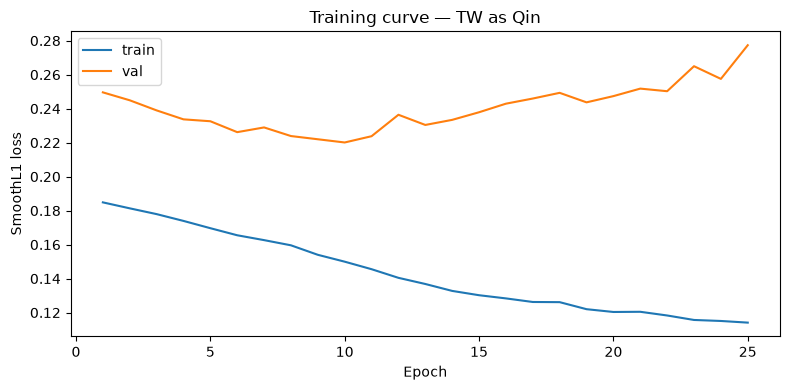

Saved training history to: outputs\problem3_formula_gru\TW_Qin_clip2_ablation\baseline\training_history.xlsx


In [7]:
# =========================
# 5. Dataset, model, training
# =========================

class SequenceDataset(Dataset):
    def __init__(self, X, y, mask):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.mask[idx]

train_loader = DataLoader(SequenceDataset(X_train, y_train, mask_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SequenceDataset(X_val, y_val, mask_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(SequenceDataset(X_test, y_test, mask_test), batch_size=BATCH_SIZE, shuffle=False)

class ResidualGRU(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.1, output_size=6):
        super().__init__()
        effective_dropout = dropout if num_layers > 1 else 0.0

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=effective_dropout,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        gru_out, _ = self.gru(x)
        last_hidden = gru_out[:, -1, :]
        last_hidden = self.dropout(last_hidden)
        return self.fc(last_hidden)

model = ResidualGRU(
    input_size=len(FEATURES),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    output_size=HORIZON,
).to(device)

criterion = nn.SmoothL1Loss(reduction="none")
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

print(model)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    observed_total = 0.0

    for xb, yb, mb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        mb = mb.to(device)

        if is_train:
            optimizer.zero_grad()

        pred = model(xb)
        element_loss = criterion(pred, yb)
        observed_count = mb.sum()
        if observed_count.item() == 0:
            continue
        loss = (element_loss * mb).sum() / observed_count

        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        total_loss += loss.item() * observed_count.item()
        observed_total += observed_count.item()

    return total_loss / max(observed_total, 1.0)

best_val_loss = float("inf")
best_state = None
patience_counter = 0
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, optimizer)
    val_loss = run_epoch(model, val_loader, optimizer=None)

    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

    if val_loss < best_val_loss - 1e-8:
        best_val_loss = val_loss
        best_state = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best val_loss={best_val_loss:.6f}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_path = OUTPUT_DIR / "training_history.xlsx"
history_df.to_excel(history_path, index=False)

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("SmoothL1 loss")
plt.title(f"Training curve — {QIN_MODE} as Qin")
plt.legend()
plt.tight_layout()
plt.show()

print("Saved training history to:", history_path)

## 6. Evaluation: residual GRU vs persistence

In [8]:
# =========================
# 6. Evaluation
# =========================

def predict_loader(model, loader):
    model.eval()
    preds, trues, masks = [], [], []

    with torch.no_grad():
        for xb, yb, mb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)
            trues.append(yb.numpy())
            masks.append(mb.numpy())

    return np.vstack(preds), np.vstack(trues), np.vstack(masks).astype(bool)

def safe_corr(a, b, method="pearson"):
    a = pd.Series(np.asarray(a).reshape(-1))
    b = pd.Series(np.asarray(b).reshape(-1))
    valid = a.notna() & b.notna()
    a = a[valid]
    b = b[valid]
    if len(a) < 3:
        return np.nan
    if a.std() == 0 or b.std() == 0:
        return np.nan
    return a.corr(b, method=method)

def direction_accuracy(true_delta, pred_delta):
    true_s = np.sign(np.asarray(true_delta).reshape(-1))
    pred_s = np.sign(np.asarray(pred_delta).reshape(-1))
    return np.mean(true_s == pred_s)

def build_metrics(y_true_ntu, y_pred_ntu, y_true_delta, y_pred_delta, observed_mask, model_name):
    rows = []

    for i, hour in enumerate(HORIZON_HOURS):
        valid = observed_mask[:, i]
        yt = y_true_ntu[valid, i]
        yp = y_pred_ntu[valid, i]
        dt = y_true_delta[valid, i]
        dp = y_pred_delta[valid, i]

        rows.append({
            "qin_mode": QIN_MODE,
            "model": model_name,
            "horizon": f"t+{i+1}",
            "horizon_hour": hour,
            "observed_count": int(valid.sum()),
            "MAE": mean_absolute_error(yt, yp),
            "RMSE": math.sqrt(mean_squared_error(yt, yp)),
            "R2": r2_score(yt, yp),
            "NTU_Pearson": safe_corr(yt, yp, "pearson"),
            "NTU_Spearman": safe_corr(yt, yp, "spearman"),
            "Delta_Pearson": safe_corr(dt, dp, "pearson"),
            "Delta_Spearman": safe_corr(dt, dp, "spearman"),
            "Direction_Accuracy": direction_accuracy(dt, dp),
        })

    valid_flat = observed_mask.reshape(-1)
    y_true_ntu_flat = y_true_ntu.reshape(-1)[valid_flat]
    y_pred_ntu_flat = y_pred_ntu.reshape(-1)[valid_flat]
    y_true_delta_flat = y_true_delta.reshape(-1)[valid_flat]
    y_pred_delta_flat = y_pred_delta.reshape(-1)[valid_flat]

    rows.append({
        "qin_mode": QIN_MODE,
        "model": model_name,
        "horizon": "overall",
        "horizon_hour": "2-12",
        "observed_count": int(valid_flat.sum()),
        "MAE": mean_absolute_error(y_true_ntu_flat, y_pred_ntu_flat),
        "RMSE": math.sqrt(mean_squared_error(y_true_ntu_flat, y_pred_ntu_flat)),
        "R2": r2_score(y_true_ntu_flat, y_pred_ntu_flat),
        "NTU_Pearson": safe_corr(y_true_ntu_flat, y_pred_ntu_flat, "pearson"),
        "NTU_Spearman": safe_corr(y_true_ntu_flat, y_pred_ntu_flat, "spearman"),
        "Delta_Pearson": safe_corr(y_true_delta_flat, y_pred_delta_flat, "pearson"),
        "Delta_Spearman": safe_corr(y_true_delta_flat, y_pred_delta_flat, "spearman"),
        "Direction_Accuracy": direction_accuracy(y_true_delta_flat, y_pred_delta_flat),
    })

    return pd.DataFrame(rows)

y_pred_delta_scaled, y_true_delta_scaled, y_observed_mask = predict_loader(model, test_loader)

pred_delta_gru = inverse_delta(y_pred_delta_scaled)
true_delta = inverse_delta(y_true_delta_scaled)

true_ntu = current_test.reshape(-1, 1) + true_delta
pred_ntu_gru = current_test.reshape(-1, 1) + pred_delta_gru
pred_ntu_gru = np.clip(pred_ntu_gru, 0, None)

pred_delta_persistence = np.zeros_like(true_delta)
pred_ntu_persistence = np.repeat(current_test.reshape(-1, 1), HORIZON, axis=1)
pred_ntu_persistence = np.clip(pred_ntu_persistence, 0, None)

metrics_persistence = build_metrics(true_ntu, pred_ntu_persistence, true_delta, pred_delta_persistence, y_observed_mask, "Persistence")
metrics_gru = build_metrics(true_ntu, pred_ntu_gru, true_delta, pred_delta_gru, y_observed_mask, f"Formula_Residual_GRU_Clip2_{FEATURE_VARIANT}")

metrics_comparison_df = pd.concat([metrics_persistence, metrics_gru], axis=0).reset_index(drop=True)

display(metrics_comparison_df)

metrics_path = OUTPUT_DIR / "metrics_comparison.xlsx"
metrics_comparison_df.to_excel(metrics_path, index=False)
print("Saved metrics to:", metrics_path)

rows = []
for sample_idx in range(len(current_test)):
    for h_idx, hour in enumerate(HORIZON_HOURS):
        rows.append({
            "qin_mode": QIN_MODE,
            "sample_idx": sample_idx,
            "base_time": pd.Timestamp(base_test_times[sample_idx]),
            "target_time": pd.Timestamp(target_test_times[sample_idx, h_idx]),
            "horizon": f"t+{h_idx+1}",
            "horizon_hour": hour,
            "current_NTU": current_test[sample_idx],
            "target_observed": bool(y_observed_mask[sample_idx, h_idx]),
            "true_NTU": true_ntu[sample_idx, h_idx] if y_observed_mask[sample_idx, h_idx] else np.nan,
            "true_delta_NTU": true_delta[sample_idx, h_idx] if y_observed_mask[sample_idx, h_idx] else np.nan,
            "pred_NTU_gru": pred_ntu_gru[sample_idx, h_idx],
            "pred_delta_gru": pred_delta_gru[sample_idx, h_idx],
            "pred_NTU_persistence": pred_ntu_persistence[sample_idx, h_idx],
            "pred_delta_persistence": 0.0,
        })

test_predictions_df = pd.DataFrame(rows)
display(test_predictions_df.head())

test_pred_path = OUTPUT_DIR / "test_predictions_long.xlsx"
test_predictions_df.to_excel(test_pred_path, index=False)
print("Saved test predictions to:", test_pred_path)

,qin_mode,model,horizon,horizon_hour,observed_count,MAE,RMSE,R2,NTU_Pearson,NTU_Spearman,Delta_Pearson,Delta_Spearman,Direction_Accuracy
0,TW,Persistence,t+1,2,465,0.018495,0.082754,0.814184,0.906990,0.979511,NaN,NaN,0.520430
1,TW,Persistence,t+2,4,464,0.031034,0.117450,0.626470,0.812842,0.954777,NaN,NaN,0.340517
2,TW,Persistence,t+3,6,463,0.036397,0.123273,0.589393,0.794049,0.935789,NaN,NaN,0.259179
3,TW,Persistence,t+4,8,462,0.036260,0.112505,0.658880,0.828729,0.923179,NaN,NaN,0.212121
4,TW,Persistence,t+5,10,461,0.037531,0.108362,0.684376,0.841370,0.910164,NaN,NaN,0.208243
5,TW,Persistence,t+6,12,460,0.044591,0.127858,0.562052,0.779597,0.891559,NaN,NaN,0.176087
6,TW,Persistence,overall,2-12,2775,0.034025,0.112948,0.655868,0.827294,0.932609,NaN,NaN,0.286486
7,TW,Formula_Residual_GRU_Clip2_baseline,t+1,2,465,0.021463,0.080296,0.825055,0.912472,0.977907,0.261096,0.092916,0.253763
8,TW,Formula_Residual_GRU_Clip2_baseline,t+2,4,464,0.032020,0.110208,0.671113,0.830410,0.951393,0.380679,0.214485,0.387931
9,TW,Formula_Residual_GRU_Clip2_baseline,t+3,6,463,0.036270,0.114003,0.648826,0.815078,0.932867,0.410817,0.262756,0.455724


Saved metrics to: outputs\problem3_formula_gru\TW_Qin_clip2_ablation\baseline\metrics_comparison.xlsx


,qin_mode,sample_idx,base_time,target_time,horizon,horizon_hour,current_NTU,target_observed,true_NTU,true_delta_NTU,pred_NTU_gru,pred_delta_gru,pred_NTU_persistence,pred_delta_persistence
0,TW,0,2026-01-23 23:00:00,2026-01-24 01:00:00,t+1,2,0.28,True,0.28,0.00,0.276850,-0.003150,0.28,0.0
1,TW,0,2026-01-23 23:00:00,2026-01-24 03:00:00,t+2,4,0.28,True,0.27,-0.01,0.280113,0.000113,0.28,0.0
2,TW,0,2026-01-23 23:00:00,2026-01-24 05:00:00,t+3,6,0.28,True,0.27,-0.01,0.280510,0.000510,0.28,0.0
3,TW,0,2026-01-23 23:00:00,2026-01-24 07:00:00,t+4,8,0.28,True,0.27,-0.01,0.284970,0.004970,0.28,0.0
4,TW,0,2026-01-23 23:00:00,2026-01-24 09:00:00,t+5,10,0.28,True,0.27,-0.01,0.282197,0.002197,0.28,0.0


Saved test predictions to: outputs\problem3_formula_gru\TW_Qin_clip2_ablation\baseline\test_predictions_long.xlsx


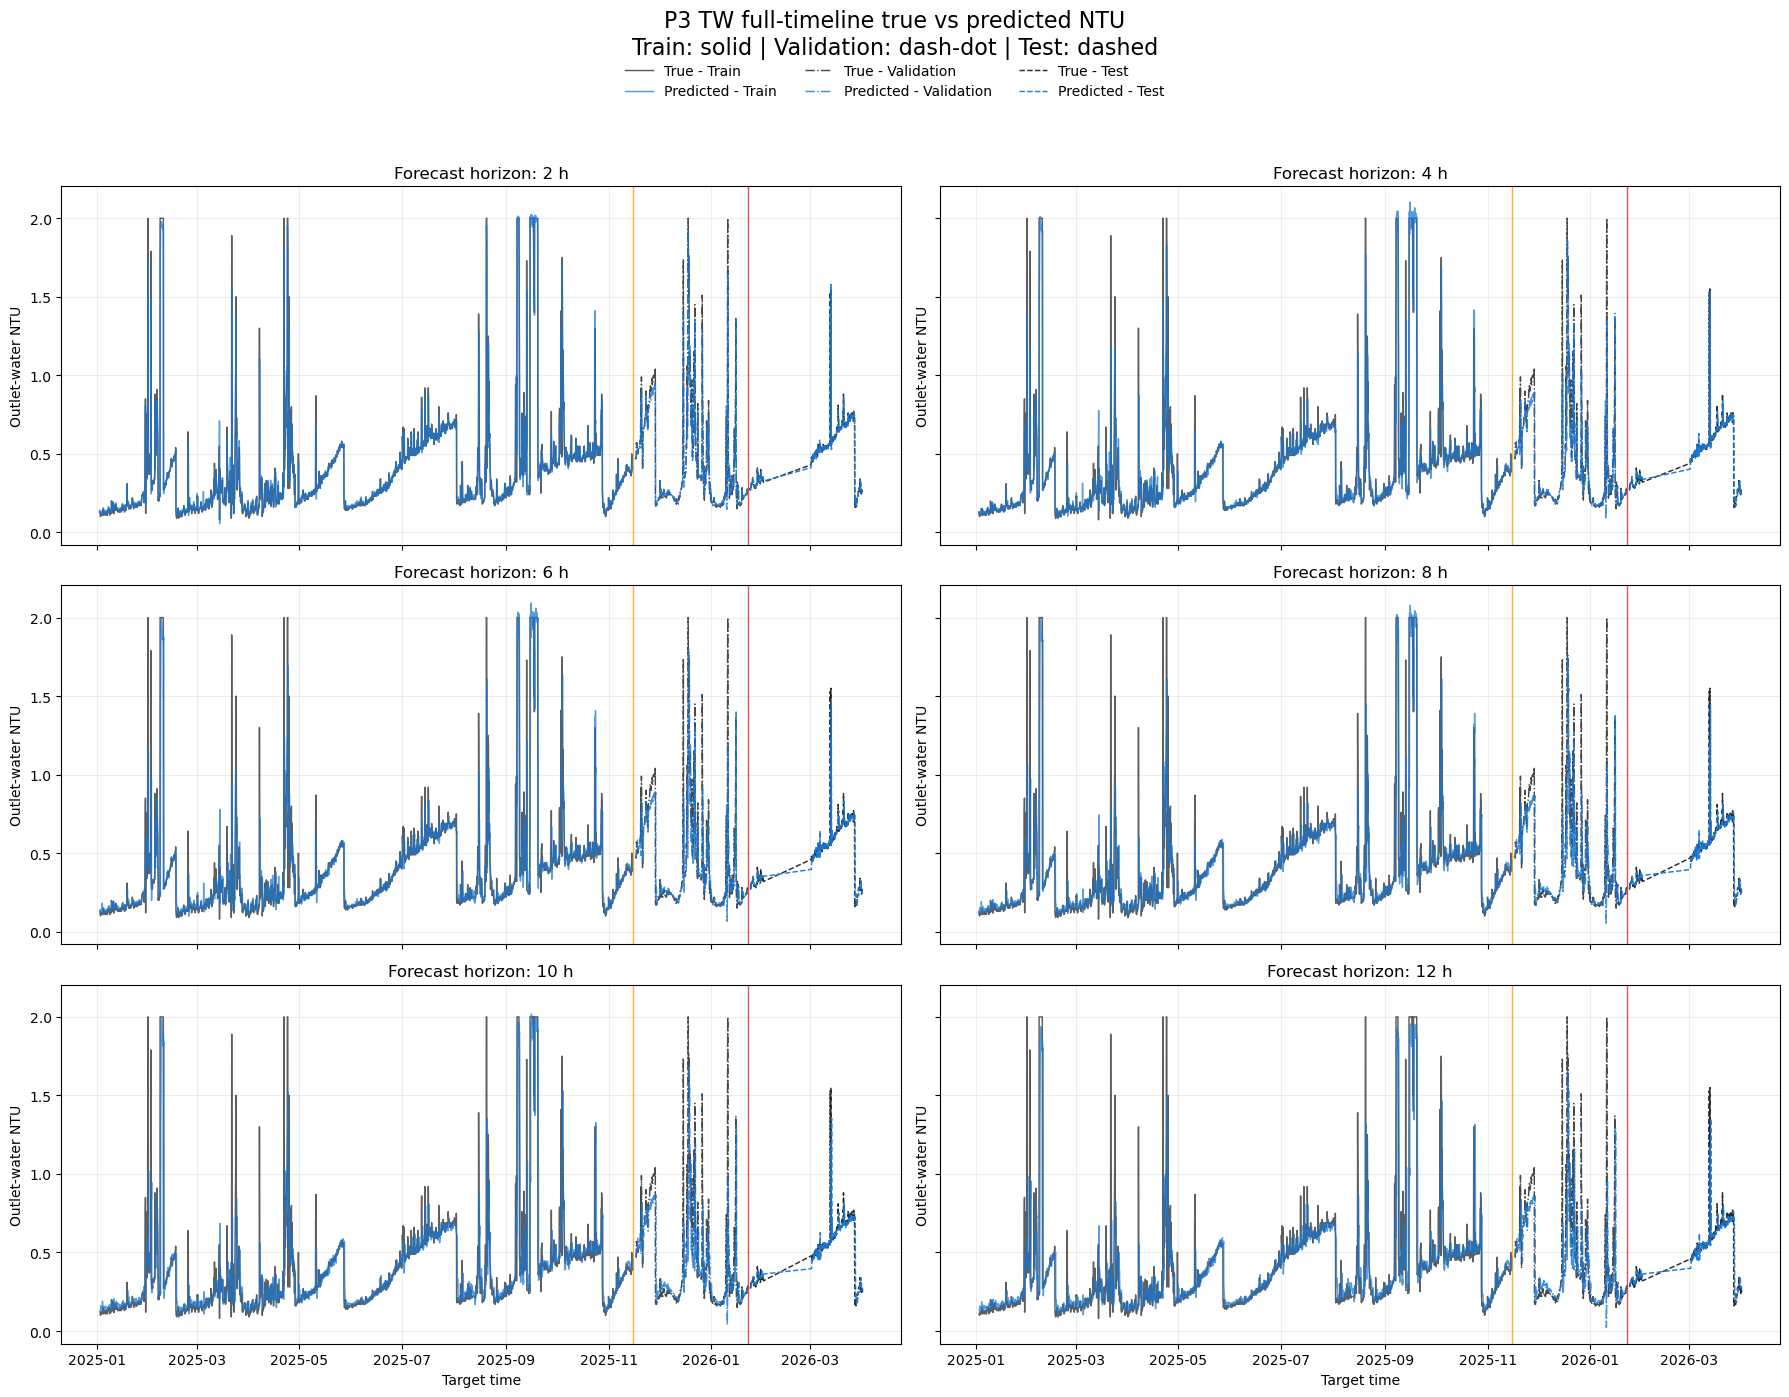

Saved full-timeline predictions to: outputs/problem3_formula_gru/TW_Qin_clip2_ablation/baseline/full_timeline_predictions.xlsx
Saved full-timeline plot to: outputs/problem3_formula_gru/TW_Qin_clip2_ablation/baseline/full_timeline_true_vs_predicted.png


In [8]:
# =========================
# 6.0 Full-timeline true vs predicted visualization
# =========================

def predict_split_for_full_plot(
    split_name,
    loader,
    current_values,
    base_times,
    target_times,
):
    pred_scaled, true_scaled, observed_mask = predict_loader(model, loader)
    pred_delta = inverse_delta(pred_scaled)
    true_delta_local = inverse_delta(true_scaled)
    pred_ntu = np.clip(current_values.reshape(-1, 1) + pred_delta, 0, None)
    true_ntu_local = current_values.reshape(-1, 1) + true_delta_local

    rows = []
    for sample_idx in range(len(current_values)):
        for h_idx, hour in enumerate(HORIZON_HOURS):
            rows.append({
                "split": split_name,
                "base_time": pd.Timestamp(base_times[sample_idx]),
                "target_time": pd.Timestamp(target_times[sample_idx, h_idx]),
                "horizon_hour": hour,
                "target_observed": bool(observed_mask[sample_idx, h_idx]),
                "true_NTU": (
                    true_ntu_local[sample_idx, h_idx]
                    if observed_mask[sample_idx, h_idx]
                    else np.nan
                ),
                "pred_NTU": pred_ntu[sample_idx, h_idx],
            })
    return pd.DataFrame(rows)


full_prediction_parts = [
    predict_split_for_full_plot(
        "Train",
        DataLoader(
            SequenceDataset(X_train, y_train, mask_train),
            batch_size=BATCH_SIZE,
            shuffle=False,
        ),
        current_train,
        base_train_times,
        target_train_times,
    ),
    predict_split_for_full_plot(
        "Validation",
        val_loader,
        current_val,
        base_val_times,
        target_val_times,
    ),
    predict_split_for_full_plot(
        "Test",
        test_loader,
        current_test,
        base_test_times,
        target_test_times,
    ),
]
full_predictions_df = pd.concat(full_prediction_parts, ignore_index=True)

full_predictions_path = OUTPUT_DIR / "full_timeline_predictions.xlsx"
full_predictions_df.to_excel(full_predictions_path, index=False)

split_styles = {
    "Train": {"linestyle": "-", "alpha": 0.72},
    "Validation": {"linestyle": "-.", "alpha": 0.82},
    "Test": {"linestyle": "--", "alpha": 0.95},
}
split_order = ["Train", "Validation", "Test"]

fig, axes = plt.subplots(3, 2, figsize=(18, 14), sharex=True, sharey=True)
axes = axes.ravel()

for h_idx, hour in enumerate(HORIZON_HOURS):
    ax = axes[h_idx]
    horizon_data = full_predictions_df[
        (full_predictions_df["horizon_hour"] == hour)
        & full_predictions_df["target_observed"]
    ].copy()

    for split_name in split_order:
        split_data = (
            horizon_data[horizon_data["split"] == split_name]
            .sort_values("target_time")
        )
        style = split_styles[split_name]
        ax.plot(
            split_data["target_time"],
            split_data["true_NTU"],
            color="#202020",
            linewidth=1.05,
            linestyle=style["linestyle"],
            alpha=style["alpha"],
            label=f"True - {split_name}",
        )
        ax.plot(
            split_data["target_time"],
            split_data["pred_NTU"],
            color="#1976D2",
            linewidth=1.05,
            linestyle=style["linestyle"],
            alpha=style["alpha"],
            label=f"Predicted - {split_name}",
        )

    ax.axvline(
        train_df["DATETIME"].max(),
        color="#F59E0B",
        linewidth=1.0,
        alpha=0.8,
    )
    ax.axvline(
        val_df["DATETIME"].max(),
        color="#DC2626",
        linewidth=1.0,
        alpha=0.8,
    )
    ax.set_title(f"Forecast horizon: {hour} h")
    ax.set_ylabel("Outlet-water NTU")
    ax.grid(alpha=0.22)

for ax in axes[-2:]:
    ax.set_xlabel("Target time")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.965),
)
fig.suptitle(
    "P3 TW full-timeline true vs predicted NTU\n"
    "Train: solid | Validation: dash-dot | Test: dashed",
    fontsize=16,
    y=0.995,
)
fig.tight_layout(rect=[0, 0, 1, 0.94])

full_timeline_plot_path = OUTPUT_DIR / "full_timeline_true_vs_predicted.png"
fig.savefig(full_timeline_plot_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved full-timeline predictions to:", full_predictions_path)
print("Saved full-timeline plot to:", full_timeline_plot_path)


## 6.1 Expanding-window blocked time-series evaluation

To measure temporal robustness, the model is retrained across four expanding
time blocks. Each fold uses an earlier training block, the immediately
following validation block for early stopping, and the next continuous block
for testing. Scalers and model parameters are fitted independently inside
each fold.

In [9]:
# =========================
# 6.1 Expanding-window blocked time-series evaluation
# =========================

def build_fold_sequences(raw_block, local_feature_scaler):
    return make_residual_sequences(
        raw_block,
        local_feature_scaler,
        USE_GAP_AWARE_SEQUENCES,
    )

def scale_with_local_scaler(values, scaler):
    shape = values.shape
    return scaler.transform(values.reshape(-1, 1)).reshape(shape).astype(np.float32)

def inverse_with_local_scaler(values, scaler):
    shape = values.shape
    return scaler.inverse_transform(values.reshape(-1, 1)).reshape(shape)

def train_blocked_fold(fold_id, fold_train_df, fold_val_df, fold_test_df):
    # Reinitialize every stochastic component so folds are reproducible.
    set_seed(SEED + fold_id)

    local_feature_scaler = StandardScaler()
    local_feature_scaler.fit(fold_train_df[FEATURES])

    train_seq = build_fold_sequences(fold_train_df, local_feature_scaler)
    val_seq = build_fold_sequences(fold_val_df, local_feature_scaler)
    test_seq = build_fold_sequences(fold_test_df, local_feature_scaler)

    (
        X_fold_train, y_fold_train_raw, mask_fold_train,
        current_fold_train, base_fold_train, target_fold_train,
    ) = train_seq
    (
        X_fold_val, y_fold_val_raw, mask_fold_val,
        current_fold_val, base_fold_val, target_fold_val,
    ) = val_seq
    (
        X_fold_test, y_fold_test_raw, mask_fold_test,
        current_fold_test, base_fold_test, target_fold_test,
    ) = test_seq

    observed_fold_train = y_fold_train_raw[mask_fold_train.astype(bool)]
    if len(observed_fold_train) == 0:
        raise ValueError(f"Fold {fold_id} has no observed training labels.")

    local_delta_scaler = StandardScaler()
    local_delta_scaler.fit(observed_fold_train.reshape(-1, 1))

    y_fold_train = scale_with_local_scaler(y_fold_train_raw, local_delta_scaler)
    y_fold_val = scale_with_local_scaler(y_fold_val_raw, local_delta_scaler)
    y_fold_test = scale_with_local_scaler(y_fold_test_raw, local_delta_scaler)

    fold_train_loader = DataLoader(
        SequenceDataset(X_fold_train, y_fold_train, mask_fold_train),
        batch_size=BATCH_SIZE, shuffle=True,
    )
    fold_val_loader = DataLoader(
        SequenceDataset(X_fold_val, y_fold_val, mask_fold_val),
        batch_size=BATCH_SIZE, shuffle=False,
    )
    fold_test_loader = DataLoader(
        SequenceDataset(X_fold_test, y_fold_test, mask_fold_test),
        batch_size=BATCH_SIZE, shuffle=False,
    )

    fold_model = ResidualGRU(
        input_size=len(FEATURES),
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        output_size=HORIZON,
    ).to(device)
    fold_optimizer = torch.optim.AdamW(
        fold_model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4,
    )

    fold_best_val = float("inf")
    fold_best_state = None
    fold_wait = 0
    fold_best_epoch = 0

    for epoch in range(1, EPOCHS + 1):
        run_epoch(fold_model, fold_train_loader, fold_optimizer)
        fold_val_loss = run_epoch(fold_model, fold_val_loader, optimizer=None)

        if fold_val_loss < fold_best_val - 1e-8:
            fold_best_val = fold_val_loss
            fold_best_state = deepcopy(fold_model.state_dict())
            fold_best_epoch = epoch
            fold_wait = 0
        else:
            fold_wait += 1

        if fold_wait >= PATIENCE:
            break

    if fold_best_state is not None:
        fold_model.load_state_dict(fold_best_state)

    pred_scaled, true_scaled, observed_mask = predict_loader(fold_model, fold_test_loader)
    pred_delta = inverse_with_local_scaler(pred_scaled, local_delta_scaler)
    true_delta = inverse_with_local_scaler(true_scaled, local_delta_scaler)
    pred_ntu = np.clip(current_fold_test.reshape(-1, 1) + pred_delta, 0, None)
    true_ntu = current_fold_test.reshape(-1, 1) + true_delta

    return {
        "best_val_loss": fold_best_val,
        "best_epoch": fold_best_epoch,
        "pred_ntu": pred_ntu,
        "true_ntu": true_ntu,
        "pred_delta": pred_delta,
        "true_delta": true_delta,
        "observed_mask": observed_mask,
        "base_times": base_fold_test,
        "target_times": target_fold_test,
    }

blocked_cv_fold_rows = []
blocked_cv_prediction_rows = []
blocked_cv_boundaries = []

if RUN_BLOCKED_CV:
    total_rows = len(full_df)
    initial_train_rows = int(total_rows * BLOCKED_CV_INITIAL_TRAIN_RATIO)
    block_rows = int(total_rows * BLOCKED_CV_BLOCK_RATIO)

    for fold_id in range(1, BLOCKED_CV_FOLDS + 1):
        train_stop = initial_train_rows + (fold_id - 1) * block_rows
        val_stop = train_stop + block_rows
        test_stop = min(val_stop + block_rows, total_rows)

        if test_stop <= val_stop:
            break

        fold_train_df = full_df.iloc[:train_stop].copy().reset_index(drop=True)
        fold_val_df = full_df.iloc[train_stop:val_stop].copy().reset_index(drop=True)
        fold_test_df = full_df.iloc[val_stop:test_stop].copy().reset_index(drop=True)

        result = train_blocked_fold(
            fold_id,
            fold_train_df,
            fold_val_df,
            fold_test_df,
        )

        blocked_cv_boundaries.append({
            "fold": fold_id,
            "train_start": fold_train_df["DATETIME"].min(),
            "train_end": fold_train_df["DATETIME"].max(),
            "val_start": fold_val_df["DATETIME"].min(),
            "val_end": fold_val_df["DATETIME"].max(),
            "test_start": fold_test_df["DATETIME"].min(),
            "test_end": fold_test_df["DATETIME"].max(),
            "train_rows": len(fold_train_df),
            "val_rows": len(fold_val_df),
            "test_rows": len(fold_test_df),
            "best_epoch": result["best_epoch"],
            "best_val_loss": result["best_val_loss"],
        })

        for h_idx, hour in enumerate(HORIZON_HOURS):
            valid = result["observed_mask"][:, h_idx]
            yt = result["true_ntu"][valid, h_idx]
            yp = result["pred_ntu"][valid, h_idx]
            mae = mean_absolute_error(yt, yp)
            rmse = math.sqrt(mean_squared_error(yt, yp))
            r2 = r2_score(yt, yp) if len(yt) >= 2 else np.nan

            blocked_cv_fold_rows.append({
                "fold": fold_id,
                "horizon": f"t+{h_idx+1}",
                "horizon_hour": hour,
                "observed_count": int(valid.sum()),
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2,
            })

        valid_flat = result["observed_mask"].reshape(-1)
        yt_flat = result["true_ntu"].reshape(-1)[valid_flat]
        yp_flat = result["pred_ntu"].reshape(-1)[valid_flat]
        blocked_cv_fold_rows.append({
            "fold": fold_id,
            "horizon": "overall",
            "horizon_hour": "2-12",
            "observed_count": int(valid_flat.sum()),
            "MAE": mean_absolute_error(yt_flat, yp_flat),
            "RMSE": math.sqrt(mean_squared_error(yt_flat, yp_flat)),
            "R2": r2_score(yt_flat, yp_flat),
        })

        for sample_idx in range(len(result["pred_ntu"])):
            for h_idx, hour in enumerate(HORIZON_HOURS):
                if not result["observed_mask"][sample_idx, h_idx]:
                    continue
                current_value = result["true_ntu"][sample_idx, h_idx] - result["true_delta"][sample_idx, h_idx]
                blocked_cv_prediction_rows.append({
                    "fold": fold_id,
                    "base_time": pd.Timestamp(result["base_times"][sample_idx]),
                    "target_time": pd.Timestamp(result["target_times"][sample_idx, h_idx]),
                    "horizon_hour": hour,
                    "true_NTU": result["true_ntu"][sample_idx, h_idx],
                    "pred_NTU_GRU": result["pred_ntu"][sample_idx, h_idx],
                    "pred_NTU_Persistence": current_value,
                })

blocked_cv_fold_metrics_df = pd.DataFrame(blocked_cv_fold_rows)
blocked_cv_predictions_df = pd.DataFrame(blocked_cv_prediction_rows)
blocked_cv_boundaries_df = pd.DataFrame(blocked_cv_boundaries)

blocked_cv_summary_rows = []
blocked_cv_comparison_rows = []

def append_blocked_metrics(rows, model_name, horizon_label, horizon_hour, group):
    yt = group["true_NTU"].to_numpy()
    yp = group[f"pred_NTU_{model_name}"].to_numpy()
    rows.append({
        "model": model_name,
        "horizon": horizon_label,
        "horizon_hour": horizon_hour,
        "observed_count": len(group),
        "MAE": mean_absolute_error(yt, yp),
        "RMSE": math.sqrt(mean_squared_error(yt, yp)),
        "R2": r2_score(yt, yp),
    })

if len(blocked_cv_predictions_df) > 0:
    for hour in HORIZON_HOURS:
        group = blocked_cv_predictions_df[
            blocked_cv_predictions_df["horizon_hour"] == hour
        ]
        append_blocked_metrics(
            blocked_cv_summary_rows, "GRU", f"{hour}h", hour, group
        )
        append_blocked_metrics(
            blocked_cv_summary_rows, "Persistence", f"{hour}h", hour, group
        )

    append_blocked_metrics(
        blocked_cv_summary_rows,
        "GRU",
        "overall",
        "2-12",
        blocked_cv_predictions_df,
    )
    append_blocked_metrics(
        blocked_cv_summary_rows,
        "Persistence",
        "overall",
        "2-12",
        blocked_cv_predictions_df,
    )

    for fold_id, fold_group in blocked_cv_predictions_df.groupby("fold"):
        for model_name in ["GRU", "Persistence"]:
            yt = fold_group["true_NTU"].to_numpy()
            yp = fold_group[f"pred_NTU_{model_name}"].to_numpy()
            blocked_cv_comparison_rows.append({
                "fold": fold_id,
                "model": model_name,
                "observed_count": len(fold_group),
                "MAE": mean_absolute_error(yt, yp),
                "RMSE": math.sqrt(mean_squared_error(yt, yp)),
                "R2": r2_score(yt, yp),
            })

blocked_cv_summary_df = pd.DataFrame(blocked_cv_summary_rows)
blocked_cv_model_comparison_df = pd.DataFrame(blocked_cv_comparison_rows)

if len(blocked_cv_summary_df) > 0:
    gru_summary = blocked_cv_summary_df[
        blocked_cv_summary_df["model"] == "GRU"
    ].set_index("horizon")
    persistence_summary = blocked_cv_summary_df[
        blocked_cv_summary_df["model"] == "Persistence"
    ].set_index("horizon")
    common_horizons = gru_summary.index.intersection(persistence_summary.index)
    blocked_cv_improvement_df = pd.DataFrame({
        "horizon": common_horizons,
        "GRU_MAE": gru_summary.loc[common_horizons, "MAE"].values,
        "Persistence_MAE": persistence_summary.loc[common_horizons, "MAE"].values,
        "MAE_improvement_pct": (
            1.0
            - gru_summary.loc[common_horizons, "MAE"].values
            / persistence_summary.loc[common_horizons, "MAE"].values
        ) * 100,
        "GRU_RMSE": gru_summary.loc[common_horizons, "RMSE"].values,
        "Persistence_RMSE": persistence_summary.loc[common_horizons, "RMSE"].values,
        "RMSE_improvement_pct": (
            1.0
            - gru_summary.loc[common_horizons, "RMSE"].values
            / persistence_summary.loc[common_horizons, "RMSE"].values
        ) * 100,
        "GRU_R2": gru_summary.loc[common_horizons, "R2"].values,
        "Persistence_R2": persistence_summary.loc[common_horizons, "R2"].values,
    })
else:
    blocked_cv_improvement_df = pd.DataFrame()

display(blocked_cv_boundaries_df)
display(blocked_cv_fold_metrics_df)
display(blocked_cv_summary_df)
display(blocked_cv_model_comparison_df)
display(blocked_cv_improvement_df)

blocked_cv_path = OUTPUT_DIR / "blocked_time_series_cv.xlsx"
with pd.ExcelWriter(blocked_cv_path) as writer:
    blocked_cv_boundaries_df.to_excel(writer, sheet_name="fold_boundaries", index=False)
    blocked_cv_fold_metrics_df.to_excel(writer, sheet_name="fold_metrics", index=False)
    blocked_cv_summary_df.to_excel(writer, sheet_name="aggregate_metrics", index=False)
    blocked_cv_model_comparison_df.to_excel(writer, sheet_name="fold_model_comparison", index=False)
    blocked_cv_improvement_df.to_excel(writer, sheet_name="gru_vs_persistence", index=False)
    blocked_cv_predictions_df.to_excel(writer, sheet_name="predictions", index=False)

print("Saved blocked time-series evaluation to:", blocked_cv_path)


,fold,train_start,train_end,val_start,val_end,test_start,test_end,train_rows,val_rows,test_rows,best_epoch,best_val_loss
0,1,2025-01-01 07:00:00,2025-08-16 17:00:00,2025-08-16 19:00:00,2025-10-01 05:00:00,2025-10-01 07:00:00,2025-11-15 17:00:00,2730,546,546,1,0.472893
1,2,2025-01-01 07:00:00,2025-10-01 05:00:00,2025-10-01 07:00:00,2025-11-15 17:00:00,2025-11-15 19:00:00,2025-12-31 05:00:00,3276,546,546,7,0.137584
2,3,2025-01-01 07:00:00,2025-11-15 17:00:00,2025-11-15 19:00:00,2025-12-31 05:00:00,2025-12-31 07:00:00,2026-02-14 17:00:00,3822,546,546,7,0.220424
3,4,2025-01-01 07:00:00,2025-12-31 05:00:00,2025-12-31 07:00:00,2026-02-14 17:00:00,2026-02-14 19:00:00,2026-04-01 05:00:00,4368,546,546,28,0.144056


,fold,horizon,horizon_hour,observed_count,MAE,RMSE,R2
0,1,t+1,2,529,0.028763,0.082484,0.850280
1,1,t+2,4,529,0.046479,0.125755,0.652009
2,1,t+3,6,529,0.059899,0.154484,0.474833
3,1,t+4,8,529,0.067777,0.167526,0.382414
4,1,t+5,10,529,0.072299,0.168046,0.378572
5,1,t+6,12,529,0.072646,0.160659,0.432008
6,1,overall,2-12,3174,0.057977,0.146401,0.528353
7,2,t+1,2,529,0.044562,0.104712,0.897392
8,2,t+2,4,529,0.068396,0.137372,0.823453
9,2,t+3,6,529,0.087505,0.167951,0.736328


,model,horizon,horizon_hour,observed_count,MAE,RMSE,R2
0,GRU,2h,2,1796,0.033386,0.091892,0.877789
1,Persistence,2h,2,1796,0.030947,0.099630,0.856340
2,GRU,4h,4,1795,0.052488,0.130072,0.755221
3,Persistence,4h,4,1795,0.050540,0.145735,0.692721
4,GRU,6h,6,1794,0.066267,0.156701,0.644919
5,Persistence,6h,6,1794,0.064009,0.174922,0.557539
6,GRU,8h,8,1793,0.074541,0.173655,0.564231
7,Persistence,8h,8,1793,0.072137,0.190761,0.474153
8,GRU,10h,10,1792,0.080727,0.184513,0.508384
9,Persistence,10h,10,1792,0.079644,0.200679,0.418463


,fold,model,observed_count,MAE,RMSE,R2
0,1,GRU,3174,0.057977,0.146401,0.528353
1,1,Persistence,3174,0.058639,0.150714,0.500154
2,2,GRU,3174,0.089363,0.179079,0.700513
3,2,Persistence,3174,0.085945,0.197675,0.635085
4,3,GRU,2217,0.059630,0.179350,0.226082
5,3,Persistence,2217,0.065241,0.207905,-0.039965
6,4,GRU,2196,0.048165,0.115351,0.612229
7,4,Persistence,2196,0.038647,0.126270,0.535336


,horizon,GRU_MAE,Persistence_MAE,MAE_improvement_pct,GRU_RMSE,Persistence_RMSE,RMSE_improvement_pct,GRU_R2,Persistence_R2
0,2h,0.033386,0.030947,-7.881469,0.091892,0.099630,7.766703,0.877789,0.856340
1,4h,0.052488,0.050540,-3.853014,0.130072,0.145735,10.747414,0.755221,0.692721
2,6h,0.066267,0.064009,-3.528371,0.156701,0.174922,10.416831,0.644919,0.557539
3,8h,0.074541,0.072137,-3.331687,0.173655,0.190761,8.967074,0.564231,0.474153
4,10h,0.080727,0.079644,-1.359794,0.184513,0.200679,8.055794,0.508384,0.418463
5,12h,0.086128,0.086668,0.622359,0.191507,0.209632,8.646224,0.470814,0.365903
6,overall,0.065573,0.063973,-2.500173,0.158503,0.174310,9.068744,0.636882,0.560842


Saved blocked time-series evaluation to: outputs\problem3_formula_gru\TW_Qin_clip2_ablation\baseline\blocked_time_series_cv.xlsx


## 7. Required-date predictions

In [10]:
# =========================
# 7. Required-date prediction helpers
# =========================

def get_time_position_map(df):
    times = pd.to_datetime(df["DATETIME"]).dt.floor("min")
    return {t: i for i, t in enumerate(times)}

time_to_pos = get_time_position_map(full_df)

def is_continuous_time_window(times, expected_freq_hours=2):
    times = pd.to_datetime(pd.Series(times))
    diffs = times.diff().dropna()
    if len(diffs) == 0:
        return True
    return (diffs == pd.Timedelta(hours=expected_freq_hours)).all()

def predict_from_base_time(base_time, require_continuous=True):
    base_time = pd.Timestamp(base_time).floor("min")
    if base_time not in time_to_pos:
        return {"ok": False, "reason": f"base_time not found: {base_time}", "base_time": base_time}

    pos = time_to_pos[base_time]
    start_pos = pos - LOOKBACK + 1
    end_pos = pos

    if start_pos < 0:
        return {"ok": False, "reason": f"not enough lookback history before {base_time}", "base_time": base_time}

    history = full_df.iloc[start_pos:end_pos + 1].copy()
    history_times = pd.to_datetime(history["DATETIME"]).dt.floor("min").tolist()

    if require_continuous and not is_continuous_time_window(history_times, EXPECTED_FREQ_HOURS):
        return {"ok": False, "reason": f"history window is not continuous before {base_time}", "base_time": base_time}

    x_scaled = feature_scaler.transform(history[FEATURES]).astype(np.float32)
    x_tensor = torch.tensor(x_scaled[None, :, :], dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        pred_delta_scaled = model(x_tensor).cpu().numpy()

    pred_delta = inverse_delta(pred_delta_scaled)[0]
    current_c = float(full_df.iloc[pos][TARGET])
    pred_ntu = np.clip(current_c + pred_delta, 0, None)
    future_times = [base_time + pd.Timedelta(hours=h) for h in HORIZON_HOURS]

    return {
        "ok": True,
        "reason": "",
        "base_time": base_time,
        "future_times": future_times,
        "horizon_hours": HORIZON_HOURS,
        "current_NTU": current_c,
        "pred_delta": pred_delta,
        "predictions": pred_ntu,
    }

exact_rows = []
for date_str in REQUESTED_DATES:
    for time_str in REQUESTED_TIMES:
        base_time = pd.Timestamp(f"{date_str} {time_str}")
        result = predict_from_base_time(base_time, require_continuous=True)

        if not result["ok"]:
            exact_rows.append({
                "qin_mode": QIN_MODE,
                "date": date_str,
                "requested_base_time": time_str,
                "base_time": base_time,
                "ok": False,
                "reason": result["reason"],
                "horizon": None,
                "horizon_hour": None,
                "future_time": None,
                "predicted_NTU": np.nan,
                "predicted_delta_NTU": np.nan,
                "current_NTU": np.nan,
            })
            continue

        for h_idx, hour in enumerate(result["horizon_hours"]):
            exact_rows.append({
                "qin_mode": QIN_MODE,
                "date": date_str,
                "requested_base_time": time_str,
                "base_time": result["base_time"],
                "ok": True,
                "reason": "",
                "horizon": f"t+{h_idx+1}",
                "horizon_hour": hour,
                "future_time": result["future_times"][h_idx],
                "predicted_NTU": result["predictions"][h_idx],
                "predicted_delta_NTU": result["pred_delta"][h_idx],
                "current_NTU": result["current_NTU"],
            })

required_exact_df = pd.DataFrame(exact_rows)
display(required_exact_df.head(20))

def find_native_base_time_for_date(date_str, start_time_str="07:00"):
    desired = pd.Timestamp(f"{date_str} {start_time_str}").floor("min")
    times = pd.to_datetime(full_df["DATETIME"]).dt.floor("min")
    same_date_times = times[times.dt.date == desired.date()].sort_values()

    if len(same_date_times) == 0:
        return None, "no data on this date"

    before_or_equal = same_date_times[same_date_times <= desired]
    if len(before_or_equal) > 0:
        candidate = before_or_equal.iloc[-1]
        diff_hours = (desired - candidate).total_seconds() / 3600
        if diff_hours <= NATIVE_BASE_TOLERANCE_HOURS:
            return candidate, ""

    nearest = same_date_times.iloc[(same_date_times - desired).abs().argmin()]
    return nearest, "nearest time used because no not-later base within tolerance"

native_rows = []
for date_str in REQUESTED_DATES:
    native_base, note = find_native_base_time_for_date(date_str, NATIVE_GRID_START_TIME)

    if native_base is None:
        native_rows.append({"qin_mode": QIN_MODE, "date": date_str, "base_time": None, "ok": False, "reason": note})
        continue

    result = predict_from_base_time(native_base, require_continuous=True)

    if not result["ok"]:
        native_rows.append({"qin_mode": QIN_MODE, "date": date_str, "base_time": native_base, "ok": False, "reason": result["reason"]})
        continue

    start = pd.Timestamp(f"{date_str} 07:00")
    end = pd.Timestamp(f"{date_str} 19:00")

    for h_idx, hour in enumerate(result["horizon_hours"]):
        ft = result["future_times"][h_idx]
        native_rows.append({
            "qin_mode": QIN_MODE,
            "date": date_str,
            "base_time": result["base_time"],
            "ok": True,
            "reason": note,
            "horizon": f"t+{h_idx+1}",
            "horizon_hour": hour,
            "future_time": ft,
            "future_time_HHMM": ft.strftime("%H:%M"),
            "predicted_NTU": result["predictions"][h_idx],
            "predicted_delta_NTU": result["pred_delta"][h_idx],
            "current_NTU": result["current_NTU"],
            "within_07_19": (ft >= start) and (ft <= end),
        })

native_grid_df = pd.DataFrame(native_rows)
display(native_grid_df)

native_times = sorted(native_grid_df["future_time_HHMM"].dropna().unique().tolist())
if len(native_times) > 0:
    native_grid_pivot_df = native_grid_df[native_grid_df["ok"] == True].pivot_table(
        index="date",
        columns="future_time_HHMM",
        values="predicted_NTU",
        aggfunc="first"
    ).reset_index()
else:
    native_grid_pivot_df = pd.DataFrame({"date": REQUESTED_DATES})

display(native_grid_pivot_df)

,qin_mode,date,requested_base_time,base_time,ok,reason,horizon,horizon_hour,future_time,predicted_NTU,predicted_delta_NTU,current_NTU
0,TW,2026-02-01,07:00,2026-02-01 07:00:00,True,,t+1,2,2026-02-01 09:00:00,0.324174,0.004174,0.32
1,TW,2026-02-01,07:00,2026-02-01 07:00:00,True,,t+2,4,2026-02-01 11:00:00,0.332165,0.012165,0.32
2,TW,2026-02-01,07:00,2026-02-01 07:00:00,True,,t+3,6,2026-02-01 13:00:00,0.330422,0.010422,0.32
3,TW,2026-02-01,07:00,2026-02-01 07:00:00,True,,t+4,8,2026-02-01 15:00:00,0.332995,0.012995,0.32
4,TW,2026-02-01,07:00,2026-02-01 07:00:00,True,,t+5,10,2026-02-01 17:00:00,0.329026,0.009026,0.32
5,TW,2026-02-01,07:00,2026-02-01 07:00:00,True,,t+6,12,2026-02-01 19:00:00,0.331629,0.011629,0.32
6,TW,2026-02-01,09:00,2026-02-01 09:00:00,True,,t+1,2,2026-02-01 11:00:00,0.335141,0.015141,0.32
7,TW,2026-02-01,09:00,2026-02-01 09:00:00,True,,t+2,4,2026-02-01 13:00:00,0.350276,0.030276,0.32
8,TW,2026-02-01,09:00,2026-02-01 09:00:00,True,,t+3,6,2026-02-01 15:00:00,0.347753,0.027753,0.32
9,TW,2026-02-01,09:00,2026-02-01 09:00:00,True,,t+4,8,2026-02-01 17:00:00,0.348905,0.028905,0.32


,qin_mode,date,base_time,ok,reason,horizon,horizon_hour,future_time,future_time_HHMM,predicted_NTU,predicted_delta_NTU,current_NTU,within_07_19
0,TW,2026-02-01,2026-02-01 07:00:00,True,,t+1,2,2026-02-01 09:00:00,09:00,0.324174,0.004174,0.32,True
1,TW,2026-02-01,2026-02-01 07:00:00,True,,t+2,4,2026-02-01 11:00:00,11:00,0.332165,0.012165,0.32,True
2,TW,2026-02-01,2026-02-01 07:00:00,True,,t+3,6,2026-02-01 13:00:00,13:00,0.330422,0.010422,0.32,True
3,TW,2026-02-01,2026-02-01 07:00:00,True,,t+4,8,2026-02-01 15:00:00,15:00,0.332995,0.012995,0.32,True
4,TW,2026-02-01,2026-02-01 07:00:00,True,,t+5,10,2026-02-01 17:00:00,17:00,0.329026,0.009026,0.32,True
5,TW,2026-02-01,2026-02-01 07:00:00,True,,t+6,12,2026-02-01 19:00:00,19:00,0.331629,0.011629,0.32,True
6,TW,2026-02-10,2026-02-10 07:00:00,True,,t+1,2,2026-02-10 09:00:00,09:00,0.328263,0.008263,0.32,True
7,TW,2026-02-10,2026-02-10 07:00:00,True,,t+2,4,2026-02-10 11:00:00,11:00,0.334863,0.014863,0.32,True
8,TW,2026-02-10,2026-02-10 07:00:00,True,,t+3,6,2026-02-10 13:00:00,13:00,0.327795,0.007795,0.32,True
9,TW,2026-02-10,2026-02-10 07:00:00,True,,t+4,8,2026-02-10 15:00:00,15:00,0.327232,0.007232,0.32,True


future_time_HHMM,date,09:00,11:00,13:00,15:00,17:00,19:00
0,2026-02-01,0.324174,0.332165,0.330422,0.332995,0.329026,0.331629
1,2026-02-10,0.328263,0.334863,0.327795,0.327232,0.322737,0.323169
2,2026-02-20,0.321152,0.326200,0.326353,0.330411,0.332688,0.337670


## 8. Sensitivity analysis

In [11]:
# =========================
# 8. Sensitivity analysis
# =========================

SENSITIVITY_VARIABLES = ["FILT. NTU", "R/W FLOW", "T/W FLOW"]
SENSITIVITY_FACTORS = [0.80, 0.90, 1.00, 1.10, 1.20]
PERTURB_LAST_K = 1

def recompute_formula_features(df_raw):
    df = df_raw.copy()

    well_level = df["C/W WELL LEVEL"].astype(float)
    well_level_safe = well_level.where(well_level.abs() > EPS, np.nan)
    well_level_safe = well_level_safe.ffill().fillna(1.0)
    well_level_safe = well_level_safe.abs() + EPS

    current_ntu = df[TARGET].astype(float)
    filt_ntu = df["FILT. NTU"].astype(float)
    rw_flow = df["R/W FLOW"].astype(float)
    tw_flow = df["T/W FLOW"].astype(float)

    qin = rw_flow if QIN_MODE == "RW" else tw_flow
    qout = tw_flow

    df["current_NTU"] = current_ntu
    df["InLoad"] = qin * filt_ntu
    df["OutLoad"] = qout * current_ntu
    df["NetLoad"] = df["InLoad"] - df["OutLoad"]
    df["inflow_term"] = DT_HOURS * qin * filt_ntu / well_level_safe
    df["outflow_term"] = DT_HOURS * qout * current_ntu / well_level_safe
    df["HRT_PROXY"] = well_level_safe / (qout.abs() + EPS)
    df["ReplaceRate"] = qout / well_level_safe
    df["DeltaC_PROXY"] = df["NetLoad"] / well_level_safe
    df["WELL_LEVEL_CHANGE"] = well_level.diff().fillna(0.0)

    return df

def predict_with_perturbation(base_time, perturb_variable, factor, perturb_last_k=1):
    base_time = pd.Timestamp(base_time).floor("min")

    if base_time not in time_to_pos:
        return {"ok": False, "reason": f"base_time not found: {base_time}"}

    pos = time_to_pos[base_time]
    start_pos = pos - LOOKBACK + 1
    end_pos = pos

    if start_pos < 0:
        return {"ok": False, "reason": f"not enough lookback history before {base_time}"}

    raw_cols = list(dict.fromkeys(["DATETIME", TARGET, "FILT. NTU", "C/W WELL LEVEL", "R/W FLOW", "T/W FLOW"]))
    history_raw = data_pre.iloc[start_pos:end_pos + 1][raw_cols].copy()

    if perturb_variable not in history_raw.columns:
        return {"ok": False, "reason": f"perturb_variable not available: {perturb_variable}"}

    idx_start = max(0, len(history_raw) - perturb_last_k)
    rows_to_perturb = history_raw.index[idx_start:]

    history_raw[perturb_variable] = history_raw[perturb_variable].astype(float)
    history_raw.loc[rows_to_perturb, perturb_variable] = (
        history_raw.loc[rows_to_perturb, perturb_variable].astype(float) * float(factor)
    )

    history_feat = recompute_formula_features(history_raw)
    x_scaled = feature_scaler.transform(history_feat[FEATURES]).astype(np.float32)
    x_tensor = torch.tensor(x_scaled[None, :, :], dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        pred_delta_scaled = model(x_tensor).cpu().numpy()

    pred_delta = inverse_delta(pred_delta_scaled)[0]
    current_c = float(history_raw.iloc[-1][TARGET])
    pred_ntu = np.clip(current_c + pred_delta, 0, None)

    return {
        "ok": True,
        "base_time": base_time,
        "current_NTU": current_c,
        "pred_delta": pred_delta,
        "predictions": pred_ntu,
        "future_times": [base_time + pd.Timedelta(hours=h) for h in HORIZON_HOURS],
    }

sensitivity_rows = []

for date_str in REQUESTED_DATES:
    base_time, note = find_native_base_time_for_date(date_str, NATIVE_GRID_START_TIME)
    if base_time is None:
        continue

    for var in SENSITIVITY_VARIABLES:
        baseline_result = predict_with_perturbation(base_time, var, 1.0, PERTURB_LAST_K)
        if not baseline_result["ok"]:
            continue

        baseline_pred = baseline_result["predictions"]

        for factor in SENSITIVITY_FACTORS:
            result = predict_with_perturbation(base_time, var, factor, PERTURB_LAST_K)

            if not result["ok"]:
                sensitivity_rows.append({
                    "qin_mode": QIN_MODE,
                    "date": date_str,
                    "base_time": base_time,
                    "variable": var,
                    "factor": factor,
                    "ok": False,
                    "reason": result["reason"],
                })
                continue

            for h_idx, hour in enumerate(HORIZON_HOURS):
                sensitivity_rows.append({
                    "qin_mode": QIN_MODE,
                    "date": date_str,
                    "base_time": base_time,
                    "variable": var,
                    "factor": factor,
                    "horizon": f"t+{h_idx+1}",
                    "horizon_hour": hour,
                    "future_time": result["future_times"][h_idx],
                    "predicted_NTU": result["predictions"][h_idx],
                    "baseline_predicted_NTU": baseline_pred[h_idx],
                    "delta_vs_factor_1": result["predictions"][h_idx] - baseline_pred[h_idx],
                    "ok": True,
                    "reason": "",
                })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df.head(30))

,qin_mode,date,base_time,variable,factor,horizon,horizon_hour,future_time,predicted_NTU,baseline_predicted_NTU,delta_vs_factor_1,ok,reason
0,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.8,t+1,2,2026-02-01 09:00:00,0.321610,0.323949,-0.002339,True,
1,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.8,t+2,4,2026-02-01 11:00:00,0.328323,0.332173,-0.003850,True,
2,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.8,t+3,6,2026-02-01 13:00:00,0.326922,0.330732,-0.003810,True,
3,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.8,t+4,8,2026-02-01 15:00:00,0.329845,0.333480,-0.003635,True,
4,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.8,t+5,10,2026-02-01 17:00:00,0.326064,0.329408,-0.003344,True,
5,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.8,t+6,12,2026-02-01 19:00:00,0.329386,0.332196,-0.002810,True,
6,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.9,t+1,2,2026-02-01 09:00:00,0.322775,0.323949,-0.001174,True,
7,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.9,t+2,4,2026-02-01 11:00:00,0.330241,0.332173,-0.001932,True,
8,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.9,t+3,6,2026-02-01 13:00:00,0.328818,0.330732,-0.001913,True,
9,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.9,t+4,8,2026-02-01 15:00:00,0.331655,0.333480,-0.001825,True,


## 9. Integrated export

In [12]:
# =========================
# 9. Integrated export
# =========================

integrated_path = OUTPUT_DIR / f"p3_formula_gru_TW_Qin_clip2_{FEATURE_VARIANT}_all_results.xlsx"

with pd.ExcelWriter(integrated_path) as writer:
    ntu_clip_report_df.to_excel(writer, sheet_name="ntu_clip_report", index=False)
    pd.DataFrame({"feature_variant": [FEATURE_VARIANT], "features": [", ".join(FEATURES)]}).to_excel(
        writer, sheet_name="feature_config", index=False
    )
    metrics_comparison_df.to_excel(writer, sheet_name="metrics_comparison", index=False)
    test_predictions_df.to_excel(writer, sheet_name="test_predictions_long", index=False)
    required_exact_df.to_excel(writer, sheet_name="exact_requested_long", index=False)
    native_grid_df.to_excel(writer, sheet_name="native_grid_long", index=False)
    native_grid_pivot_df.to_excel(writer, sheet_name="native_grid_pivot", index=False)
    sensitivity_df.to_excel(writer, sheet_name="sensitivity", index=False)
    history_df.to_excel(writer, sheet_name="training_history", index=False)
    blocked_cv_boundaries_df.to_excel(writer, sheet_name="cv_boundaries", index=False)
    blocked_cv_fold_metrics_df.to_excel(writer, sheet_name="cv_fold_metrics", index=False)
    blocked_cv_summary_df.to_excel(writer, sheet_name="cv_aggregate", index=False)
    blocked_cv_model_comparison_df.to_excel(writer, sheet_name="cv_model_compare", index=False)
    blocked_cv_improvement_df.to_excel(writer, sheet_name="cv_gru_vs_persist", index=False)

print("Saved integrated results to:", integrated_path)
print("Done.")

Saved integrated results to: outputs\problem3_formula_gru\TW_Qin_clip2_ablation\baseline\p3_formula_gru_TW_Qin_clip2_baseline_all_results.xlsx
Done.


## 10. Report description

中文：

> 本文基于简化物料衡算构造公式分项特征，包括当前出厂水浊度、入流项、出流项、水力停留时间代理、清水池水位变化、滤后水浊度、原水流量和出厂水流量。模型以过去 24 小时的公式分项序列为输入，采用直接多步 GRU 预测未来 2、4、6、8、10、12 小时相对于当前出厂水浊度的变化量，再与当前 NTU 相加得到未来出厂水浊度预测值。